In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ulrikthygepedersen/online-retail-dataset/online_retail.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/ulrikthygepedersen/online-retail-dataset/online_retail.csv', encoding='latin1')

print(df.shape)
print(df.columns.tolist())
print(df.head())

(541909, 8)
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [3]:
# Очистка данных
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['CustomerID'] = df['CustomerID'].astype(int)

print(df.shape)
print(df.dtypes)

(397884, 9)
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
TotalPrice            float64
dtype: object


In [4]:
# RFM расчёт
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print(rfm.shape)
print(rfm.head(10))
print(rfm.describe())

(4338, 4)
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40
5       12352       36          8   2506.04
6       12353      204          1     89.00
7       12354      232          1   1079.40
8       12355      214          1    459.40
9       12356       23          3   2811.43
         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2054.266460
std     1721.808492   100.014169     7.697998    8989.230441
min    12346.000000     1.000000     1.000000       3.750000
25%    13813.250000    18.000000     1.000000     307.415000
50%    15299.500000    51.000000     2.000000     674.485000
75%    16778.750000   142.000000     5.000000    1661.740000
max    18287.00000

In [5]:
# RFM скоринг (1-4, где 4 — лучший)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Сегменты
def segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    if r >= 3 and f >= 3:
        return 'Champions'
    elif r >= 3 and f < 3:
        return 'Recent Customers'
    elif r < 3 and f >= 3:
        return 'Loyal Customers'
    else:
        return 'At Risk'

rfm['Segment'] = rfm.apply(segment, axis=1)
print(rfm['Segment'].value_counts())

Segment
Champions           1523
At Risk             1504
Recent Customers     665
Loyal Customers      646
Name: count, dtype: int64


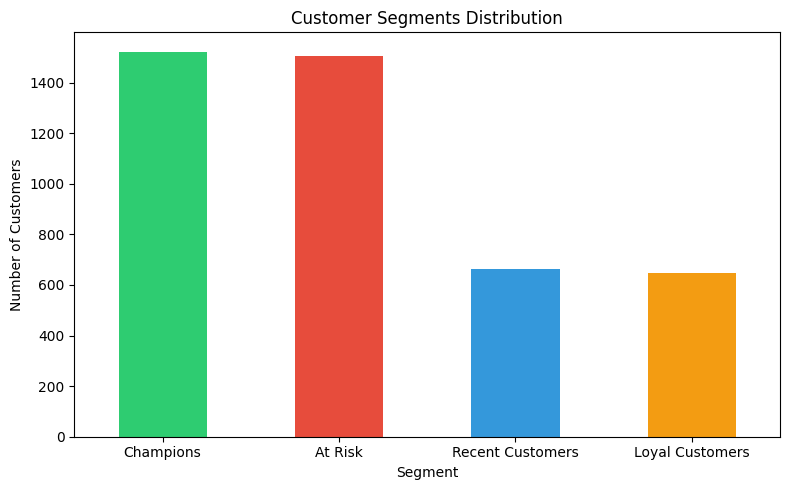

In [6]:
# График 1 — распределение сегментов
plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']
rfm['Segment'].value_counts().plot(kind='bar', color=colors)
plt.title('Customer Segments Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

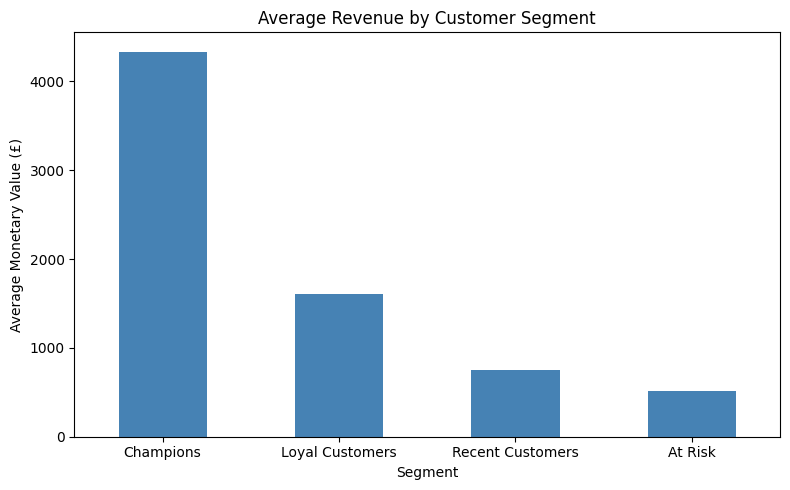

In [7]:
# График 2 — средний Monetary по сегментам
plt.figure(figsize=(8, 5))
rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title('Average Revenue by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Average Monetary Value (£)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

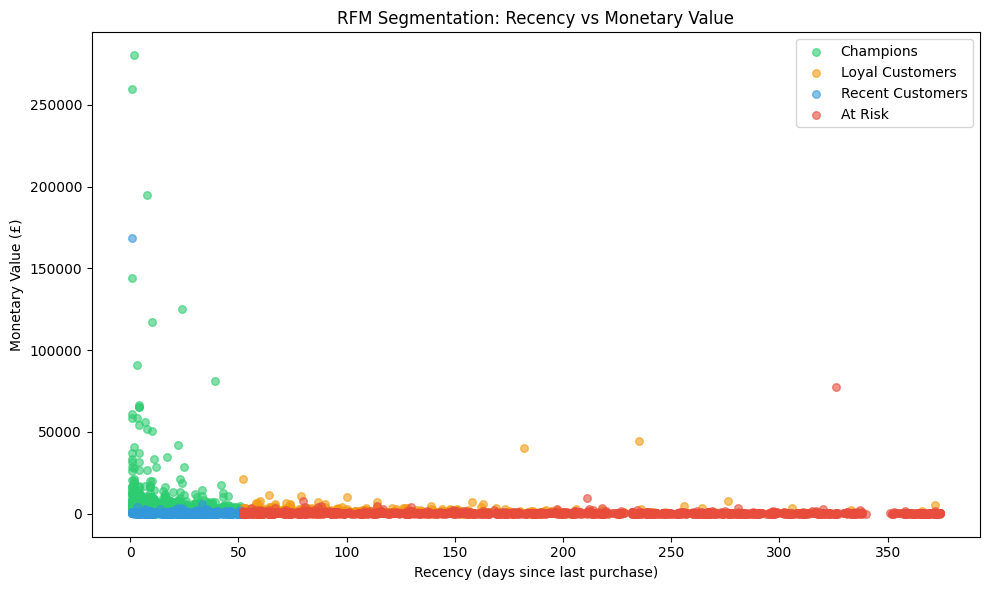

In [8]:
# График 3 — RFM scatter plot (Recency vs Monetary)
plt.figure(figsize=(10, 6))
colors_map = {'Champions': '#2ecc71', 'Loyal Customers': '#f39c12', 
              'Recent Customers': '#3498db', 'At Risk': '#e74c3c'}

for segment, color in colors_map.items():
    subset = rfm[rfm['Segment'] == segment]
    plt.scatter(subset['Recency'], subset['Monetary'], 
                c=color, label=segment, alpha=0.6, s=30)

plt.title('RFM Segmentation: Recency vs Monetary Value')
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Monetary Value (£)')
plt.legend()
plt.tight_layout()
plt.show()

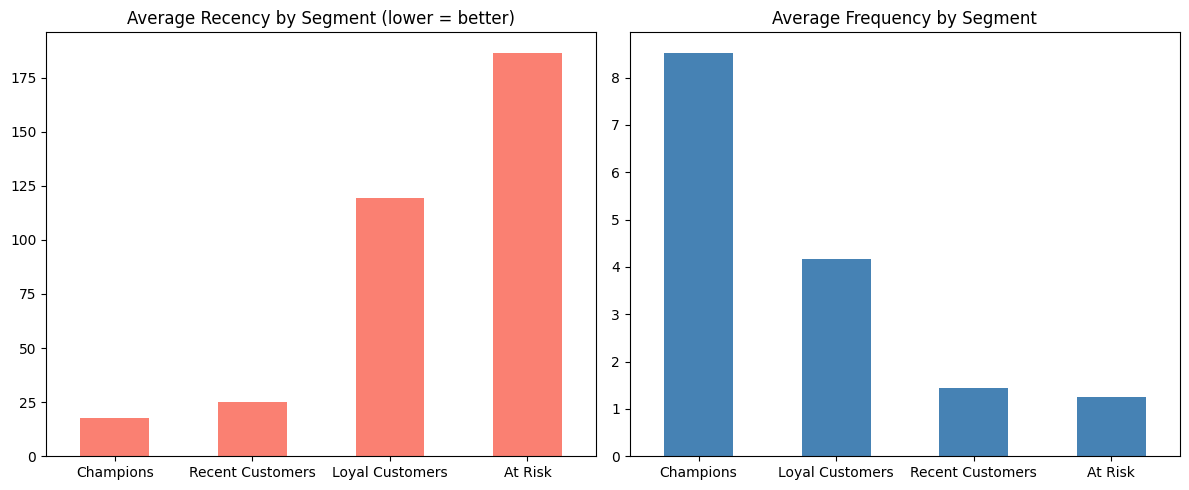

In [9]:
# График 4 — средний Recency и Frequency по сегментам
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

rfm.groupby('Segment')['Recency'].mean().sort_values().plot(kind='bar', ax=axes[0], color='salmon')
axes[0].set_title('Average Recency by Segment (lower = better)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

rfm.groupby('Segment')['Frequency'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Average Frequency by Segment')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()